
# Pipeline de Visão Computacional para Classificação de Objetos

## Introdução

Este projeto apresenta um pipeline simples de Visão Computacional utilizando OpenCV para detectar e classificar objetos com base em características visuais.

O cenário simulado representa uma triagem automática de objetos utilizando processamento de imagens e classificação baseada em regras simples.

## Objetivo

O objetivo deste projeto é desenvolver um pipeline de Visão Computacional capaz de detectar objetos presentes em uma imagem, extrair características relevantes e realizar classificações simples baseadas na área dos objetos detectados.

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Carregamento da Imagem

Nesta etapa é realizada a leitura da imagem original contendo os objetos utilizados na análise.

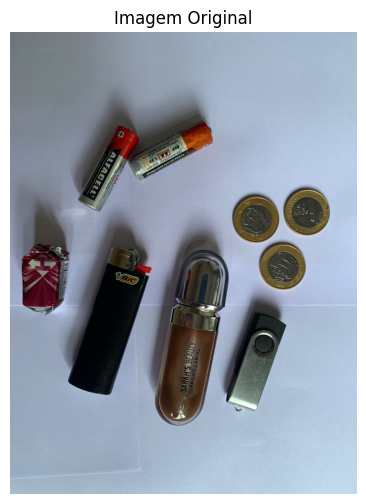

In [40]:
imagem = cv2.imread("imagens/objetos.jpg")

imagem_rgb = cv2.cvtColor(
    imagem,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,6))
plt.imshow(imagem_rgb)
plt.title("Imagem Original")
plt.axis("off")
plt.show()

## Pré-processamento da Imagem

Nesta etapa a imagem é convertida para escala de cinza, suavizada utilizando Gaussian Blur e segmentada através de limiarização binária.

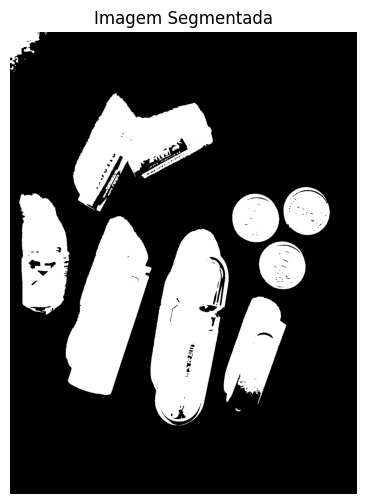

In [41]:
gray = cv2.cvtColor(
    imagem,
    cv2.COLOR_BGR2GRAY
)

blur = cv2.GaussianBlur(
    gray,
    (5,5),
    0
)

_, thresh = cv2.threshold(
    blur,
    120,
    255,
    cv2.THRESH_BINARY_INV
)

plt.figure(figsize=(8,6))
plt.imshow(thresh, cmap="gray")
plt.title("Imagem Segmentada")
plt.axis("off")
plt.show()

## Detecção de Objetos

Nesta etapa são detectados os contornos dos objetos presentes na imagem utilizando a função findContours do OpenCV.

In [42]:
contornos, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

## Extração de Características e Classificação

Para cada objeto detectado foram calculadas características como área, perímetro, largura e altura.

A classificação foi realizada com base na área dos objetos detectados.

In [43]:
dados = []

for c in contornos:

    area = cv2.contourArea(c)

    # Ignorar pequenos ruídos
    if area > 4000:

        perimetro = cv2.arcLength(c, True)

        x, y, w, h = cv2.boundingRect(c)

        # ==========================
        # CLASSIFICAÇÃO
        # ==========================

        if area < 15000:
            classe = "Pequeno"

        elif area < 45000:
            classe = "Médio"

        else:
            classe = "Grande"

        # ==========================
        # SALVAR DADOS
        # ==========================

        dados.append([
            area,
            perimetro,
            w,
            h,
            classe
        ])

        # ==========================
        # DESENHAR CAIXA
        # ==========================

        cv2.rectangle(
            imagem_rgb,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            1
        )

        # ==========================
        # FUNDO DO TEXTO
        # ==========================

        cv2.rectangle(
            imagem_rgb,
            (x, y),
            (x + 90, y + 25),
            (255, 0, 0),
            -1
        )

        # ==========================
        # TEXTO
        # ==========================

        cv2.putText(
            imagem_rgb,
            classe,
            (x + 5, y + 17),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1
        )

## Resultado Final

A imagem abaixo apresenta os objetos detectados e classificados automaticamente pelo sistema.

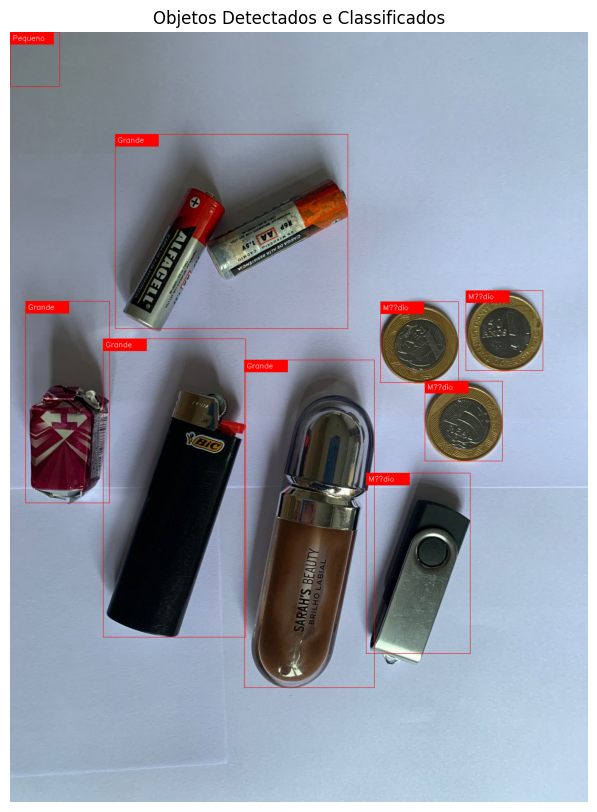

In [44]:
plt.figure(figsize=(15,10))
plt.imshow(imagem_rgb)
plt.title("Objetos Detectados e Classificados")
plt.axis("off")
plt.show()

## Tabela de Características

In [45]:
df = pd.DataFrame(
    dados,
    columns=[
        "Área",
        "Perímetro",
        "Largura",
        "Altura",
        "Classe"
    ]
)

df

,Área,Perímetro,Largura,Altura,Classe
0,44604.0,1300.312831,216,375,Médio
1,20657.5,539.286358,161,166,Médio
2,122764.5,2111.966722,270,681,Grande
3,107225.0,1644.018453,296,620,Grande
4,21189.0,545.872144,162,168,Médio
5,54470.0,1505.685414,174,419,Grande
6,20011.0,832.264060,160,166,Médio
7,87115.0,2684.237920,483,404,Grande
8,6363.5,622.492421,103,113,Pequeno


## Relação com Redes Neurais Convolucionais

Neste projeto, as características dos objetos foram definidas manualmente utilizando medidas como área, largura e altura.

Em aplicações mais avançadas, Redes Neurais Convolucionais (CNNs) conseguem aprender automaticamente características relevantes das imagens, como bordas, formas, texturas e padrões complexos, sem necessidade de regras manuais.

Isso permite maior robustez em cenários com iluminação variável, fundos complexos e grande quantidade de dados.

## Limitações do Método

O método apresentou limitações relacionadas à iluminação, sombras e proximidade entre os objetos.

Além disso, objetos com brilho elevado, como moedas, podem gerar reflexos que interferem na segmentação da imagem.

## Conclusão

O projeto demonstrou a construção de um pipeline simples de Visão Computacional utilizando OpenCV para detectar, analisar e classificar objetos com base em características visuais.

Os resultados obtidos mostram como técnicas clássicas de processamento de imagens podem ser utilizadas em sistemas de automação e triagem visual.